#1 Hierarchical Reinforcement Learning

**1-Step SMDP Q-Learning in a Taxi Environment (Based on Sutton, Precup & Singh, 1999)**
This project involves implementing 1-step Semi-Markov Decision Process (SMDP) Q-Learning based on the seminal 1999 paper “Between MDPs and semi-MDPs: A Framework for Temporal Abstraction in Reinforcement Learning” by Sutton, Precup, and Singh.

Key highlights of the project include:

A custom implementation of SMDP Q-learning using the theoretical framework outlined in Section 3 of the paper

The algorithm accounts for temporally extended actions (options) and updates the Q-values based on both reward accumulation and elapsed time (duration) during those actions

The environment used is a simplified Taxi domain, which provides a clear and intuitive setting for testing hierarchical or temporally abstracted policies

Focus is placed on building strong intuition for SMDPs by directly connecting the theory to practical implementation

#2 Environment Description
The environment for this task is the taxi domain, illustrated in Fig. 1. It is a 5x5 matrix, where each cell is a position your taxi can stay at. There is a single passenger who can be either picked up or dropped off, or is being transported. There are four designated
locations in the grid world indicated by R(ed), G(reen), Y(ellow), and B(lue). When the episode starts, the taxi starts off at a random square and the passenger is at a random location. The taxi drives to the passenger’s location, picks up the passenger, drives to the
passenger’s destination (another one of the four specified locations), and then drops off the passenger. Once the passenger is dropped off, the episode ends.


There are 500 discrete states since there are 25 taxi positions, 5 possible locations of the passenger (including the case when the passenger is in the taxi), and 4 destination locations. Note that there are 400 states that can actually be reached during an episode. The missing states correspond to situations in which the passenger is at the same location as their destination, as this typically signals the end of an episode. Four additional states can be observed right after a successful episodes, when both the passenger and the taxi are at the destination. This gives a total of 404 reachable discrete states.


Passenger locations: 0: R(ed); 1: G(reen); 2: Y(ellow); 3: B(lue); 4: in taxi Destinations: 0: R(ed); 1: G(reen); 2: Y(ellow); 3: B(lue)
Rewards:
 - -1 per step unless other reward is triggered.
 -  +20 delivering passenger.
 - -10 executing ”pickup” and ”drop-off” actions illegally.
The discount factor is taken to be γ = 0.9.

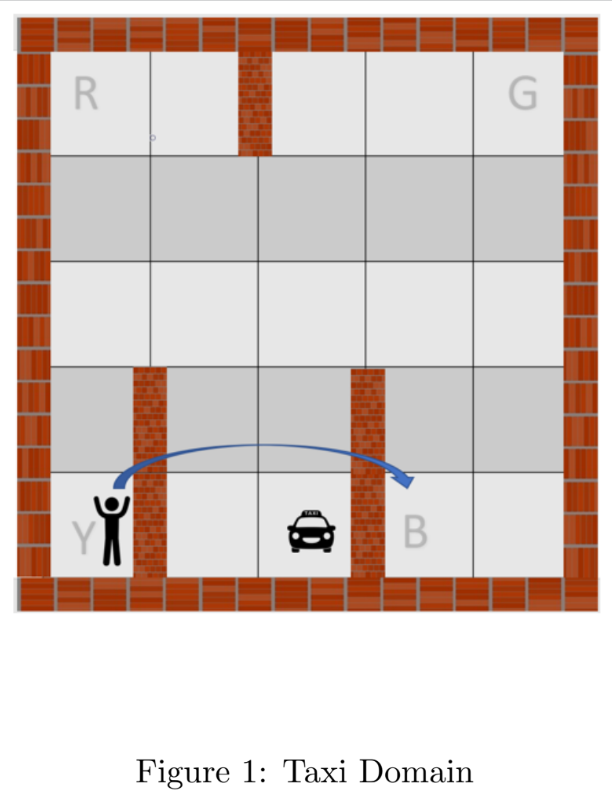

#3 Actions and Options
**Actions:** There are 6 discrete deterministic actions: 0: move south; 1: move north; 2: move east; 3: move west; 4: pick passenger up; and 5: drop passenger off.


**Options:** Options to move the taxi to each of the four designated locations, executable when the taxi is not already there.


We will be experimenting with OpenAI Gym’s Taxi-v3 environment.


First, we implement the single step **SMDP Q-learning** for solving the taxi problem. A rough sketch of the algorithm is as follows: Given the set of options,

- Execute the current selected option to termination (e.g. use epsilon greedy $Q(s, o))$.
- Computer $r(s, o)$.
- Update $Q(st, o)$.


1. Plot reward curves and visualize the learned Q-values.

2. Is there an alternate set of options that we can use to solve this problem, such that this set and the given options to move the taxi are mutually exclusive? If so, run both algorithms with this alternate set of options and compare performance with the algorithms run on the options to move the taxi.


In [ ]:
# Import the required libraries
!pip install gym  matplotlib
!pip install numpy==1.23.5
import warnings

warnings.simplefilter("ignore")



One step SMDP Q learning

In [ ]:
# helper function to decode the current state
def decode_state(state):
    taxi_row, taxi_col, passenger_loc, dest_idx = env.decode(state)
    return taxi_row, taxi_col, passenger_loc, dest_idx

def epsilon_greedy_policy(state, Q, epsilon):

    if np.random.rand() < epsilon:
        # Explore: Random action/option
        return np.random.randint(num_options + 2)
    else:
        # Exploit: Choose the best action with random tie-breaking
        max_value = np.max(Q[state])

        # Get all actions with the max value
        best_actions = np.where(Q[state] == max_value)[0]

        # Randomly select one if there's a tie
        return np.random.choice(best_actions)


# Function to execute a primitive action and return reward and next state
def execute_action(state, action):
    next_state, reward, done, _ = env.step(action)
    return next_state, reward, done

In [ ]:
import numpy as np
import gym
import matplotlib.pyplot as plt
from collections import defaultdict

# Set random seed for reproducibility
np.random.seed(42)

# Initialize the Taxi-v3 environment
env = gym.make("Taxi-v3").env


# Define the four designated locations (R, G, Y, B) based on the grid
locations = {
    'R': (0, 0),  # Red
    'G': (0, 4),  # Green
    'Y': (4, 0),  # Yellow
    'B': (4, 3)   # Blue
}

# Define the options: one for each location to move the taxi to R, G, Y, B
# Options are indexed as: 0 (to R), 1 (to G), 2 (to Y), 3 (to B), 4 (pickup), 5 (dropoff)
num_options = 4  # Options to move to R, G, Y, B
num_actions = env.action_space.n  # 6 actions: south, north, east, west, pickup, dropoff


# Function to execute the options
def SMDP_execute_option_to_location(state, target_loc):

    taxi_row, taxi_col, _, _ = decode_state(state)
    target_row, target_col = locations[list(locations.keys())[target_loc]]
    total_reward = 0
    steps = 0
    gamma_factor=1
    current_state = state
    done = False
    discounted_reward = 0  #  Properly discounted cumulative reward
    while (taxi_row, taxi_col) != (target_row, target_col):  # Loop until the option's goal is reached

        # Determine the best action to move towards the target
        if taxi_row < target_row:
            action = 0  # Move south
        elif taxi_row > target_row:
            action = 1  # Move north
        elif taxi_col < target_col:
            action = 2  # Move east
        else:
            action = 3  # Move west

        # Take a step
        next_state, reward, done, _ = env.step(action)
        #  Apply discounted reward accumulation
        discounted_reward += gamma_factor * reward
        gamma_factor *= gamma  # Update discount factor
        total_reward += reward
        steps += 1

        #  Decode the new state
        next_taxi_row, next_taxi_col, _, _ = decode_state(next_state)
        # print(next_taxi_row,next_taxi_col,"next taxi location")

        #  Check if the taxi reached the goal after the step
        if (next_taxi_row, next_taxi_col) == (target_row, target_col):
            current_state=next_state
            break  # Stop moving once the target is reached

        #  Wall detection: Only apply wall avoidance logic if the taxi hasn't reached the target
        if (next_taxi_row, next_taxi_col) == (taxi_row, taxi_col):
            # Apply corrective actions based on position
            if taxi_row == 4 and taxi_col < target_col:
                action_set = [1, 1, 2]  # Move up twice, then east
            elif taxi_row == 4 and taxi_col > target_col:
                action_set = [1, 1, 3]  # Move up twice, then west
            elif taxi_row == 0 and taxi_col < target_col:
                action_set = [0, 0, 2]  # Move down, then east
            elif taxi_row == 0 and taxi_col > target_col:
                action_set = [0, 0, 3]  # Move down, then west
            else:
                action_set = []

            # Execute corrective actions
            for action in action_set:
                next_state, reward, done, _ = env.step(action)
                #  Apply discounted reward accumulation
                discounted_reward += gamma_factor * reward
                gamma_factor *= gamma  # Update discount factor
                total_reward += reward
                steps += 1
                current_state = next_state
                # Update taxi coordinates
                next_taxi_row, next_taxi_col, _, _ = decode_state(next_state)
                # print(next_taxi_row, next_taxi_col,"wall encountered")

                # Stop if the target location is reached
                if (next_taxi_row, next_taxi_col) == (target_row, target_col):
                    break

        # Update current state and taxi's position
        current_state = next_state
        taxi_row, taxi_col, _, _ = decode_state(current_state)

    return current_state,discounted_reward, steps, done,total_reward


def SMDP_Q_learning(gamma,alpha,num_episodes):
    # Initialize Q-table for state-option pairs: Q(s, o)
    Q = defaultdict(lambda: np.zeros(num_options + 2))  # +2 for pickup and dropoff actions
    rewards_SMDP = []  # To store total reward per episode
    for episode in range(num_episodes):
        state = env.reset()
        total_reward = 0
        done = False
        steps=0
        reward_sum=0
        while not done:
            # Select an option or action using epsilon-greedy policy
            option = epsilon_greedy_policy(state, Q, epsilon)
            if option < num_options:  # Option to move to a location
                # print(option)
                next_state, option_reward, steps,done,reward_sum = SMDP_execute_option_to_location(state, option)
                # Compute the discounted reward for the option
                r_option = option_reward
                # Update Q-value for the state-option pair
                Q[state][option] = Q[state][option] + alpha * (
                    r_option + (gamma ** steps) * np.max(Q[next_state]) - Q[state][option]
                )
            else:
                # Execute primitive action (pickup or dropoff)
                action = option # Map to pickup (4) or dropoff (5)
                next_state, reward, done = execute_action(state, action)
                r_option = reward
                # Update Q-value for the state-action pair
                Q[state][option] = Q[state][option] + alpha * (
                    r_option + gamma * np.max(Q[next_state]) - Q[state][option]
                )

            total_reward += reward_sum
            state = next_state
        rewards_SMDP.append(total_reward)
    return rewards_SMDP, Q

# Hyperparameters
alpha_values=[0.01, 0.1, 1.0]
gamma_values= [0.8, 0.9, 1.0]
epsilon_values= [0.001, 0.01, 0.1]
num_episodes=400 # Lower number of episodes while hyper parameter tuning
max_reward= float('-inf')
best_alpha=None
best_gamma=None
best_epsilon=None

# Hyperparameter tuning
for alpha in alpha_values:
  for gamma in gamma_values:
    for epsilon in epsilon_values:
      rewards_SMDP, Q = SMDP_Q_learning(gamma,alpha,num_episodes)
      if sum(rewards_SMDP)>max_reward: # Checking cumulative reward
        max_reward=sum(rewards_SMDP)
        best_alpha=alpha
        best_gamma=gamma
        best_epsilon=epsilon
print('max_reward is',max_reward,' best alpha value is',best_alpha,' best gamma value is',best_gamma,' best epsilon value is',best_epsilon)



/usr/local/lib/python3.11/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


max_reward is -24188  best alpha value is 1.0  best gamma value is 1.0  best epsilon value is 0.1


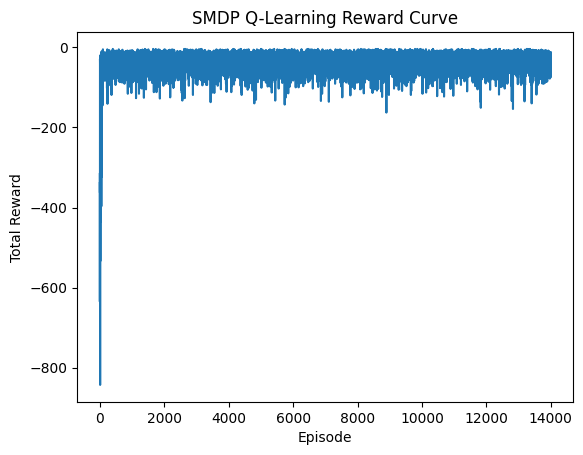

In [ ]:
num_episodes=14000 # Higher episodes for best hyperparameters
rewards_SMDP,Q_SMDP= SMDP_Q_learning(best_gamma,best_alpha,num_episodes)
# Plot the reward curve
plt.plot(rewards_SMDP)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('SMDP Q-Learning Reward Curve')
plt.show()

In [ ]:
options = ["R", "G", "Y", "B", "P", "D"]  # Options: Move to Y, R, G, B, Pickup, Dropoff


In [ ]:
import numpy as np

def visualize_option_policy(Q):
    grid = np.full((5, 5), " ")  # Create empty grid

    for state in Q.keys():
        taxi_row, taxi_col, _, _ = decode_state(state)
        best_option = np.argmax(Q[state])  # Choose best option
        grid[taxi_row, taxi_col] = options[best_option]  # Use option label

    for row in grid:
        print(" ".join(row))  # Print row by row

visualize_option_policy(Q_SMDP)


R R G G G
R G R B G
R R R G G
R R G B R
Y Y B B B


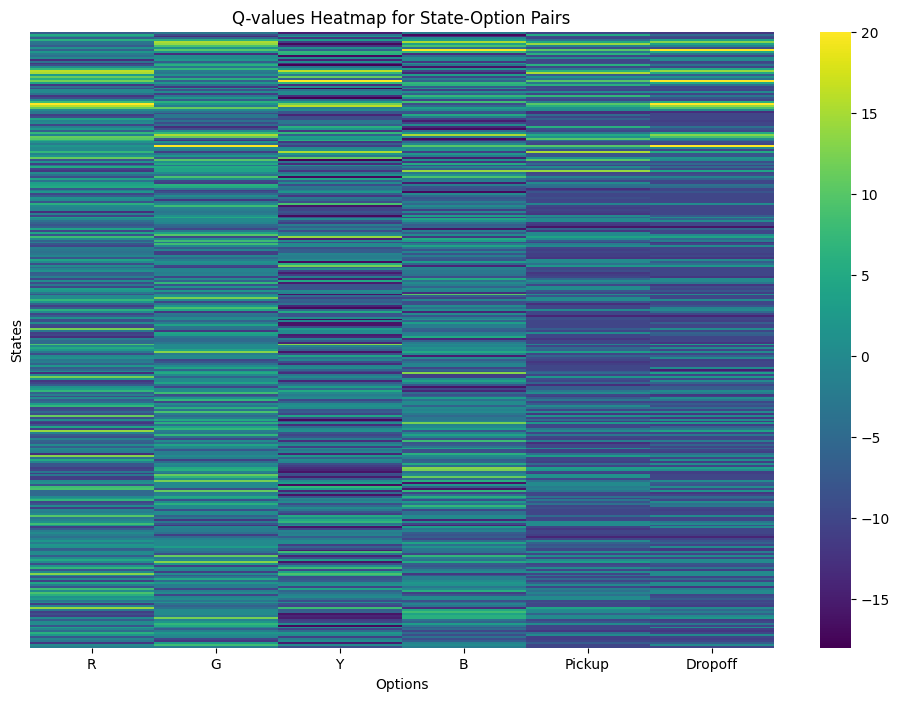

In [ ]:
import seaborn as sns

# Prepare data for heatmap
states = list(Q_SMDP.keys())
options = ['R', 'G', 'Y', 'B', 'Pickup', 'Dropoff']

q_matrix = np.array([Q_SMDP[state] for state in states])

plt.figure(figsize=(12, 8))
sns.heatmap(q_matrix, annot=False, cmap='viridis', xticklabels=options, yticklabels=False)
plt.xlabel("Options")
plt.ylabel("States")
plt.title("Q-values Heatmap for State-Option Pairs")
plt.show()


In [ ]:
# The new option in which the taxi first moves to row 2 and then moves to the corresponding column and then move to the destiantion row
def SMDP_execute_new_option_to_location(state, target_loc):
    taxi_row, taxi_col, _, _ = decode_state(state)
    target_row, target_col = locations[list(locations.keys())[target_loc]]

    discounted_reward = 0  #  Properly discounted cumulative reward
    gamma_factor = 1  #  Tracks gamma^t for discounting
    steps = 0
    current_state = state
    done = False
    total_reward=0

    while (taxi_row, taxi_col) != (target_row, target_col):
        #  Determine the best action to move towards the target
        if taxi_row != 2 and taxi_col != target_col:
            if taxi_row < 2:
                action = 0  # Move south
            elif taxi_row > 2:
                action = 1  # Move north
        elif taxi_row == 2 and taxi_col != target_col:
            if taxi_col < target_col:
                action = 2  # Move east
            elif taxi_col > target_col:
                action = 3  # Move west
        else:
            if taxi_row < target_row:
                action = 0  # Move south
            elif taxi_row > target_row:
                action = 1  # Move north

        #  Take a step in the environment
        next_state, reward, done, _ = env.step(action)

        #  Apply discounted reward accumulation
        discounted_reward += gamma_factor * reward
        gamma_factor *= gamma  # Update discount factor
        total_reward+= reward
        steps += 1
        next_taxi_row, next_taxi_col, _, _ = decode_state(next_state)

        #  Stop moving once the target is reached
        if (next_taxi_row, next_taxi_col) == (target_row, target_col):
            current_state = next_state
            break

        current_state = next_state
        taxi_row, taxi_col, _, _ = decode_state(current_state)

    return current_state, discounted_reward, steps, done, total_reward


# Function for training loop
def new_SMDP_Q_learning(gamma,alpha,num_epidoes):

    # Initialize Q-table for state-option pairs: Q(s, o)
    Q = defaultdict(lambda: np.zeros(num_options + 2))  # +2 for pickup and dropoff actions
    rewards_SMDP = []  # To store total reward per episode
    for episode in range(num_episodes):
        state = env.reset()
        total_reward = 0
        done = False
        steps=0
        sum_reward=0
        while not done:
            # Select an option or action using epsilon-greedy policy
            option = epsilon_greedy_policy(state, Q, epsilon)
            if option < num_options:  # Option to move to a location
                next_state, option_reward, steps,done,sum_reward = SMDP_execute_new_option_to_location(state, option)
                # Compute the discounted reward for the option
                r_option = option_reward
                # Update Q-value for the state-option pair
                Q[state][option] = Q[state][option] + alpha * (
                    r_option + (gamma ** steps) * np.max(Q[next_state]) - Q[state][option]
                )
            else:
                # Execute primitive action (pickup or dropoff)
                action = option - num_options + 4  # Map to pickup (4) or dropoff (5)
                next_state, reward, done = execute_action(state, action)
                r_option = reward
                # Update Q-value for the state-action pair
                Q[state][option] = Q[state][option] + alpha * (
                    r_option + gamma * np.max(Q[next_state]) - Q[state][option]
                )

            total_reward += sum_reward
            state = next_state
        rewards_SMDP.append(total_reward)
    return rewards_SMDP, Q

In [ ]:
rewards_SMDP_new,Q_SMDP_new= new_SMDP_Q_learning(best_gamma,best_alpha,num_episodes)

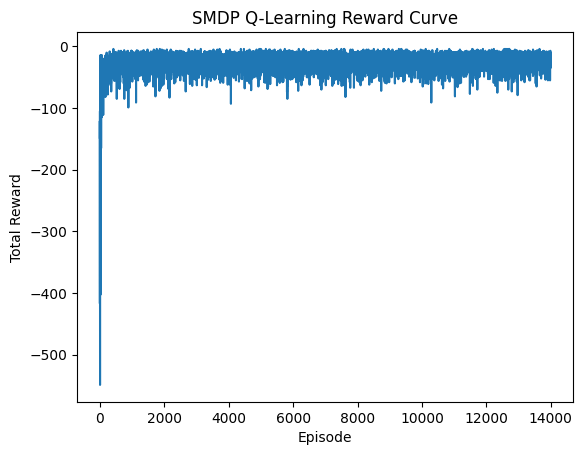

In [ ]:
# Plot the reward curve
plt.plot(rewards_SMDP_new)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('SMDP Q-Learning Reward Curve')
plt.show()

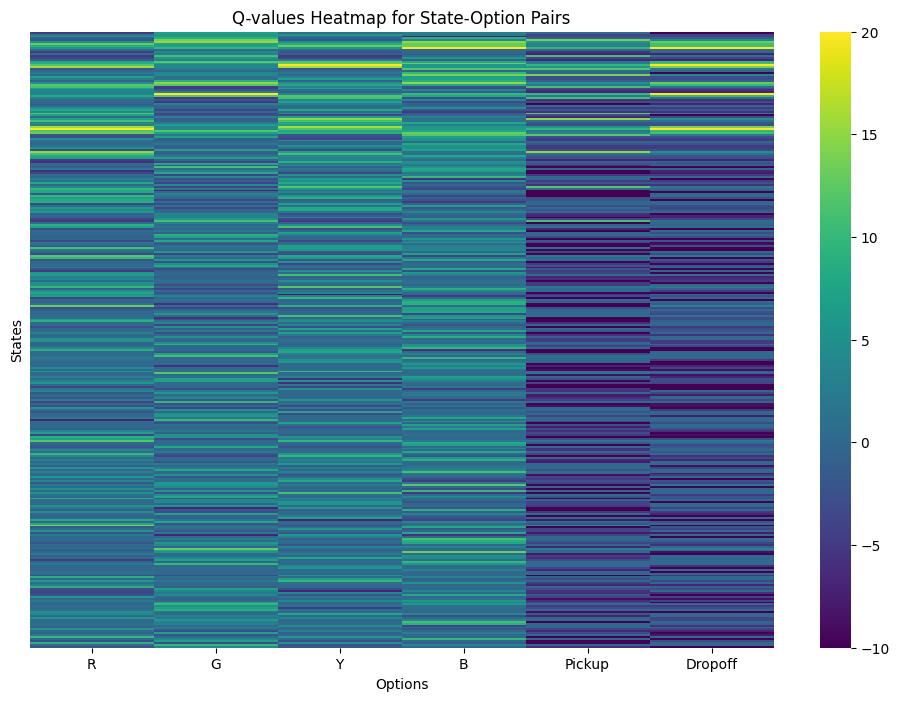

In [ ]:
# Prepare data for heatmap
states = list(Q_SMDP_new.keys())
options = ['R', 'G', 'Y', 'B', 'Pickup', 'Dropoff']

q_matrix = np.array([Q_SMDP_new[state] for state in states])

plt.figure(figsize=(12, 8))
sns.heatmap(q_matrix, annot=False, cmap='viridis', xticklabels=options, yticklabels=False)
plt.xlabel("Options")
plt.ylabel("States")
plt.title("Q-values Heatmap for State-Option Pairs")
plt.show()

In [ ]:
visualize_option_policy(Q_SMDP_new)

G G R B G
R R B G G
R R G B B
B Y G G Y
G R R G G
